In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

%matplotlib inline

In [36]:
ticker_symbol = 'BTC-USD'

# Fetch Bitcoin data from Yahoo Finance
df = yf.download(ticker_symbol, start='2015-01-01', end='2024-09-30')

df=df.reset_index()
df.head()

[*********************100%%**********************]  1 of 1 completed


,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-01,320.434998,320.434998,314.002991,314.248993,314.248993,8036550
1,2015-01-02,314.079010,315.838989,313.565002,315.032013,315.032013,7860650
2,2015-01-03,314.846008,315.149994,281.082001,281.082001,281.082001,33054400
3,2015-01-04,281.145996,287.230011,257.612000,264.195007,264.195007,55629100
4,2015-01-05,265.084015,278.341003,265.084015,274.473999,274.473999,43962800


In [37]:
df.shape

(3560, 7)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3560 non-null   datetime64[ns]
 1   Open       3560 non-null   float64       
 2   High       3560 non-null   float64       
 3   Low        3560 non-null   float64       
 4   Close      3560 non-null   float64       
 5   Adj Close  3560 non-null   float64       
 6   Volume     3560 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 194.8 KB


In [39]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,3560,3560.000000,3560.000000,3560.000000,3560.000000,3560.000000,3.560000e+03
mean,2019-11-15 12:00:00.000000256,18478.936191,18897.642920,18033.468855,18496.101743,18496.101743,1.817609e+10
min,2015-01-01 00:00:00,176.897003,211.731003,171.509995,178.102997,178.102997,7.860650e+06
25%,2017-06-08 18:00:00,2379.564941,2507.847534,2287.572571,2392.270081,2392.270081,9.848245e+08
50%,2019-11-15 12:00:00,9377.975098,9549.722656,9232.566406,9381.900879,9381.900879,1.475210e+10
75%,2022-04-23 06:00:00,29812.612793,30345.909668,29282.421387,29838.826172,29838.826172,2.908641e+10
max,2024-09-29 00:00:00,73079.375000,73750.070312,71334.093750,73083.500000,73083.500000,3.509679e+11
std,NaN,19812.379499,20252.700123,19333.106905,19823.924102,19823.924102,1.919850e+10


In [40]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
3555,2024-09-25,64302.589844,64804.503906,62945.375000,63143.144531,63143.144531,25078377700
3556,2024-09-26,63138.546875,65790.796875,62669.269531,65181.019531,65181.019531,36873129847
3557,2024-09-27,65180.664062,66480.695312,64852.992188,65790.664062,65790.664062,32058813449
3558,2024-09-28,65792.179688,66255.531250,65458.035156,65887.648438,65887.648438,15243637984
3559,2024-09-29,65888.898438,66069.343750,65450.015625,65635.304688,65635.304688,14788214575


In [41]:
# Initialize a flag to track if all values are the same
all_same = True

# Check if the 'Close' and 'Adj Close' values are the same for each row
for i in range(len(df)):
    if df['Close'][i] != df['Adj Close'][i]:
        all_same = False
        break

# Drop 'Adj Close' if all values are the same
if all_same:
    df = df.drop(columns='Adj Close')

# Display the updated DataFrame
df.head()

,Date,Open,High,Low,Close,Volume
0,2015-01-01,320.434998,320.434998,314.002991,314.248993,8036550
1,2015-01-02,314.079010,315.838989,313.565002,315.032013,7860650
2,2015-01-03,314.846008,315.149994,281.082001,281.082001,33054400
3,2015-01-04,281.145996,287.230011,257.612000,264.195007,55629100
4,2015-01-05,265.084015,278.341003,265.084015,274.473999,43962800


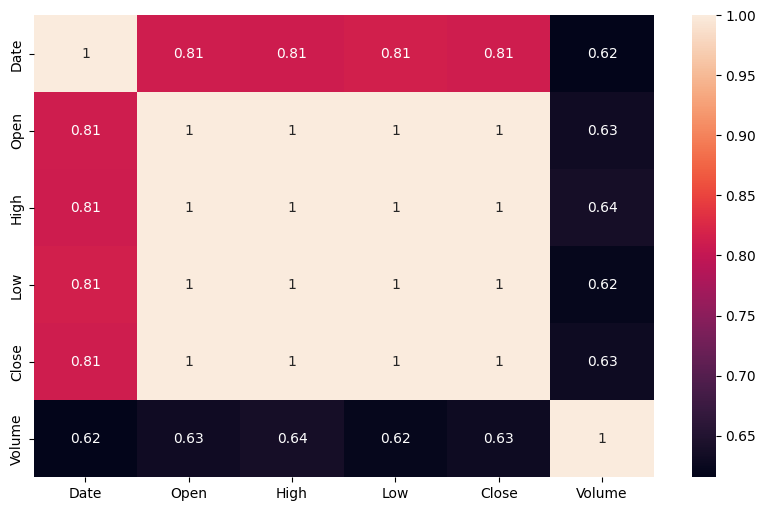

In [43]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [44]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

In [45]:
df.head()

,Date,Open,High,Low,Close,Volume,Month,Day,Year
0,2015-01-01,320.434998,320.434998,314.002991,314.248993,8036550,1,1,2015
1,2015-01-02,314.079010,315.838989,313.565002,315.032013,7860650,1,2,2015
2,2015-01-03,314.846008,315.149994,281.082001,281.082001,33054400,1,3,2015
3,2015-01-04,281.145996,287.230011,257.612000,264.195007,55629100,1,4,2015
4,2015-01-05,265.084015,278.341003,265.084015,274.473999,43962800,1,5,2015


In [46]:
df['Year'].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype=int32)

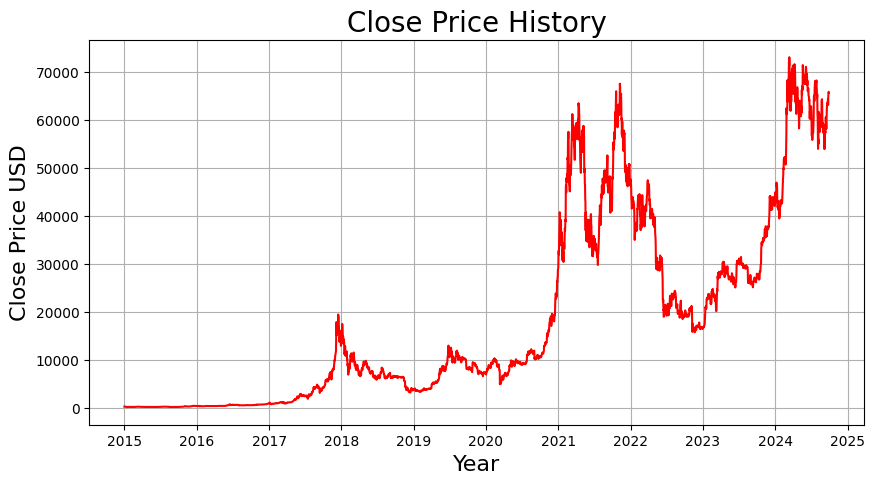

In [51]:
#plotting the data
plt.figure(figsize=(10,5))
plt.title('Close Price History',fontsize=20)
plt.plot(df['Date'],df['Close'], color='r')
plt.xlabel('Year', fontsize=16)
plt.ylabel('Close Price USD', fontsize = 16)
plt.grid(True)
plt.show()

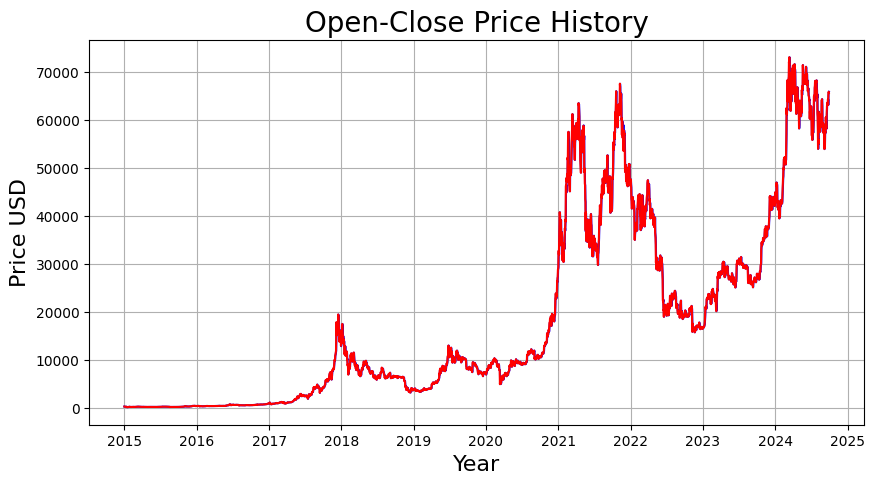

In [52]:
#plotting the data
plt.figure(figsize=(10,5))
plt.title('Open-Close Price History',fontsize=20)
plt.plot(df['Date'],df['Open'], color='b')
plt.plot(df['Date'],df['Close'], color='r')
plt.xlabel('Year', fontsize=16)
plt.ylabel('Price USD', fontsize = 16)
plt.grid(True)
plt.show()

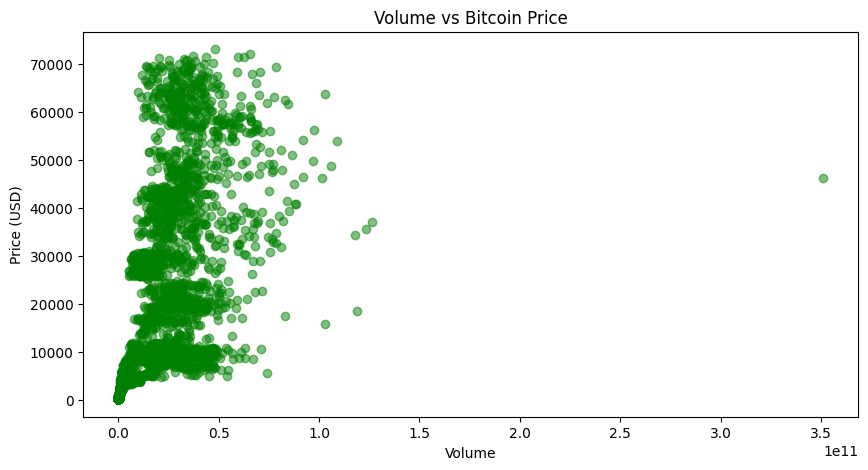

In [53]:
plt.figure(figsize=(10,5))
plt.scatter(df['Volume'], df['Close'], alpha=0.5, color='g')
plt.title('Volume vs Bitcoin Price')
plt.xlabel('Volume')
plt.ylabel('Price (USD)')
plt.show()

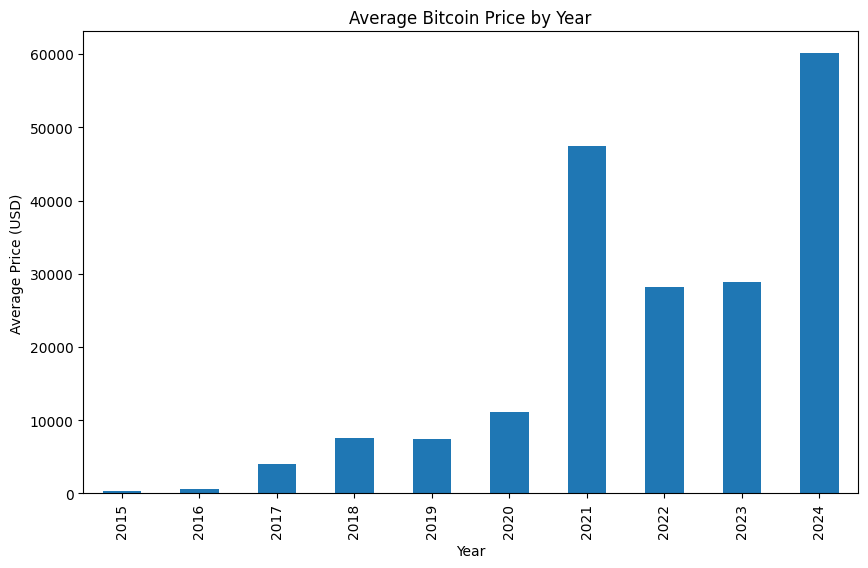

In [55]:
monthly_mean = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(10,6))
monthly_mean.plot(kind='bar')
plt.title('Average Bitcoin Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Price (USD)')
plt.show()

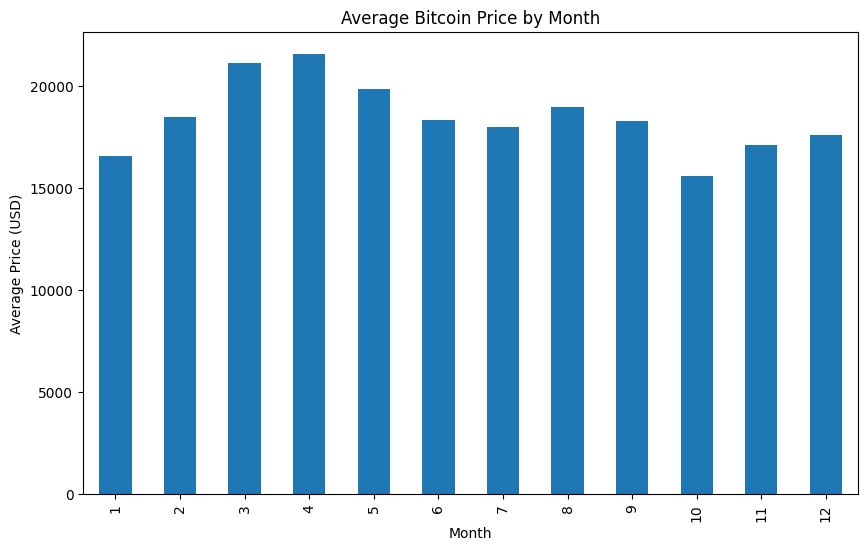

In [54]:

# Group by month to check seasonality
monthly_mean = df.groupby('Month')['Close'].mean()

plt.figure(figsize=(10,6))
monthly_mean.plot(kind='bar')
plt.title('Average Bitcoin Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price (USD)')
plt.show()


In [14]:
gb_year=df.groupby("Year")


df_2015=gb_year.get_group(2015)
df_2016=gb_year.get_group(2016)
df_2017=gb_year.get_group(2017)
df_2018=gb_year.get_group(2018)
df_2019=gb_year.get_group(2019)
df_2020=gb_year.get_group(2020)
df_2021=gb_year.get_group(2021)
df_2022=gb_year.get_group(2022)
df_2023=gb_year.get_group(2023)
df_2024=gb_year.get_group(2024)

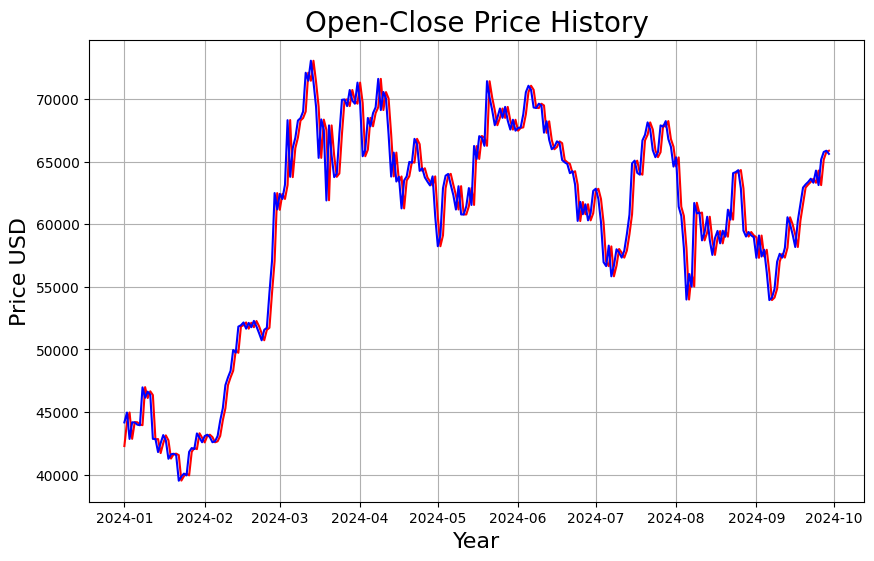

In [49]:
#plotting the data
plt.figure(figsize=(10,5))
plt.title('Open-Close Price History',fontsize=20)
plt.plot(df_2024['Date'],df_2024['Open'], color='r')
plt.plot(df_2024['Date'],df_2024['Close'], color='b')
plt.xlabel('Year', fontsize=16)
plt.ylabel('Price USD', fontsize = 16)
plt.grid(True)
plt.show()

In [56]:
# Group the data by 'Year' and 'Month'
monthly_avg = df.groupby(['Year', 'Month'])['Close'].mean().unstack(level=0)


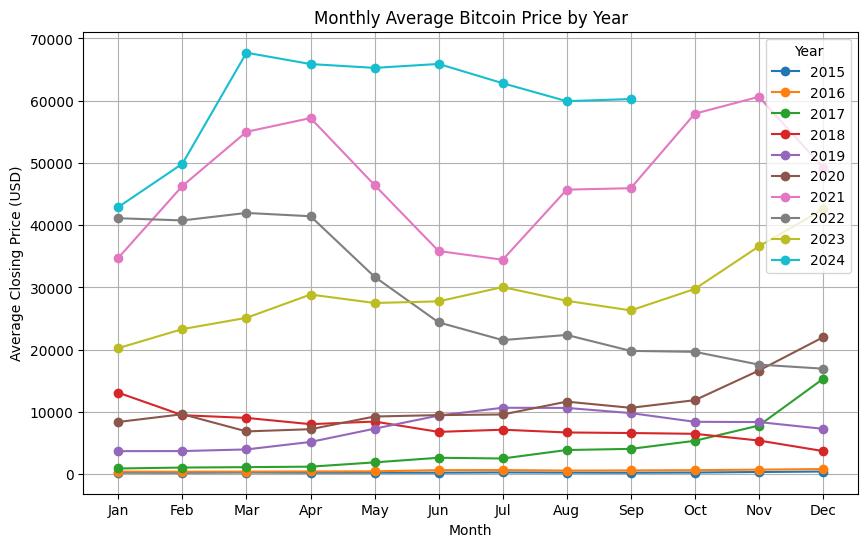

In [57]:
import matplotlib.pyplot as plt

# Plot the monthly average closing prices for each year
plt.figure(figsize=(10, 6))

for year in monthly_avg.columns:
    plt.plot(monthly_avg.index, monthly_avg[year], label=f'{year}', marker='o')

plt.title('Monthly Average Bitcoin Price by Year')
plt.xlabel('Month')
plt.ylabel('Average Closing Price (USD)')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.grid(True)
plt.show()


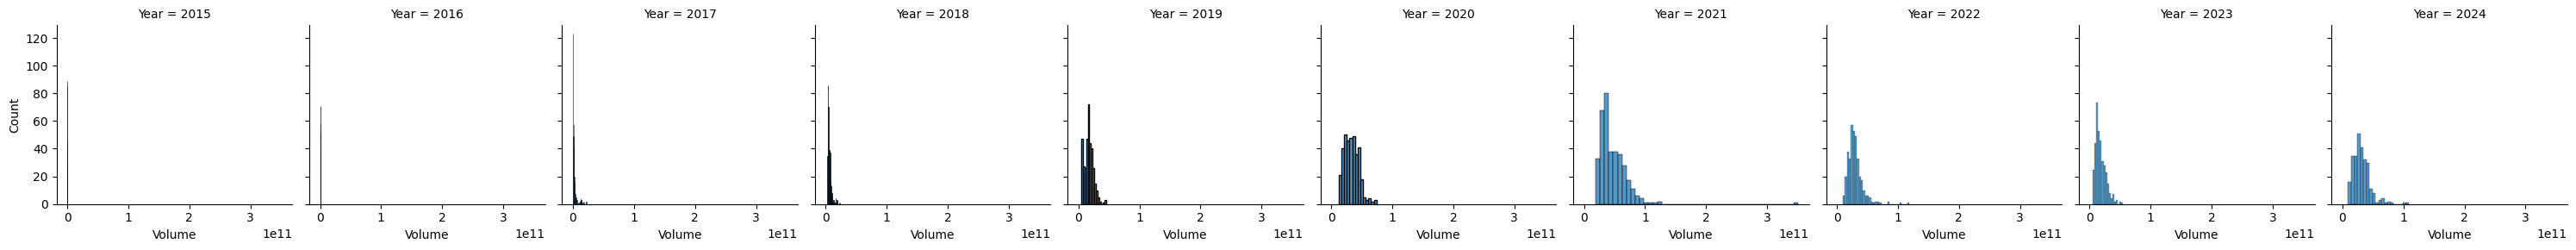

In [71]:
g=sns.FacetGrid(data=df, col="Year")
g.map(sns.histplot, "Volume")

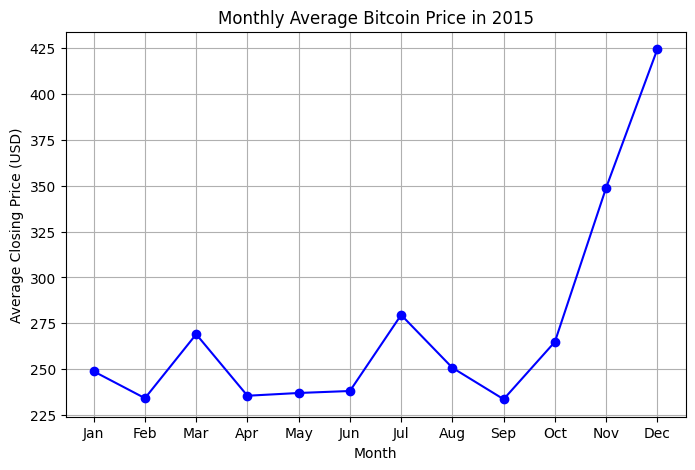

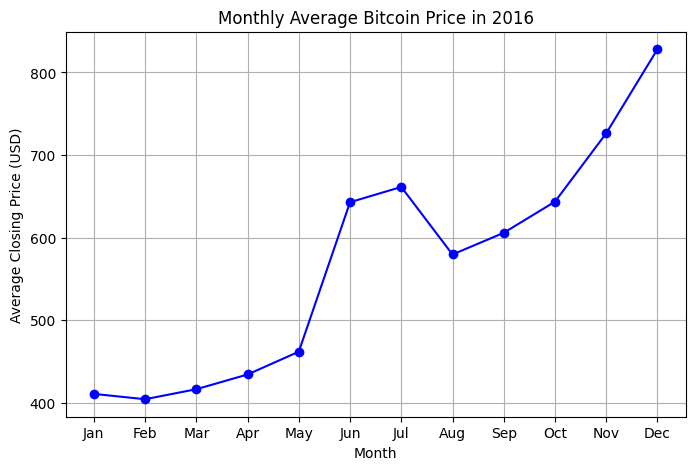

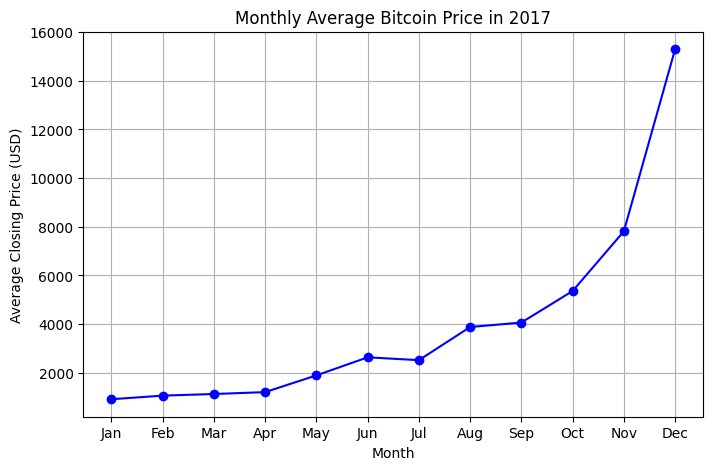

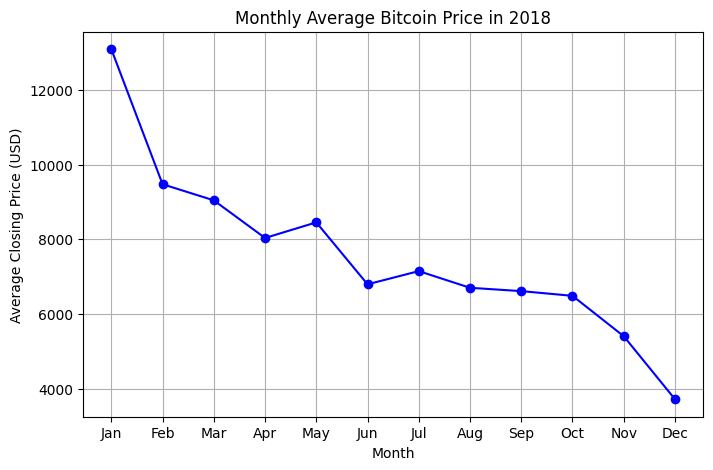

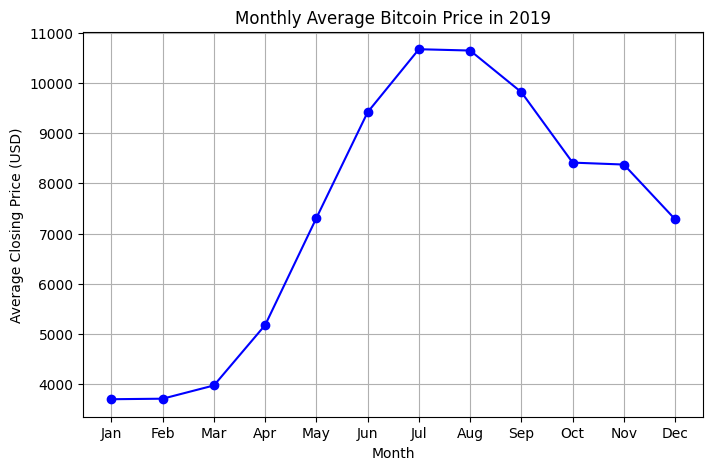

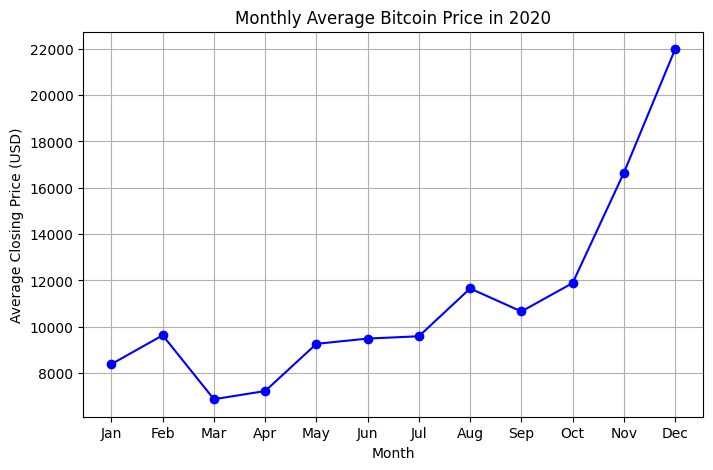

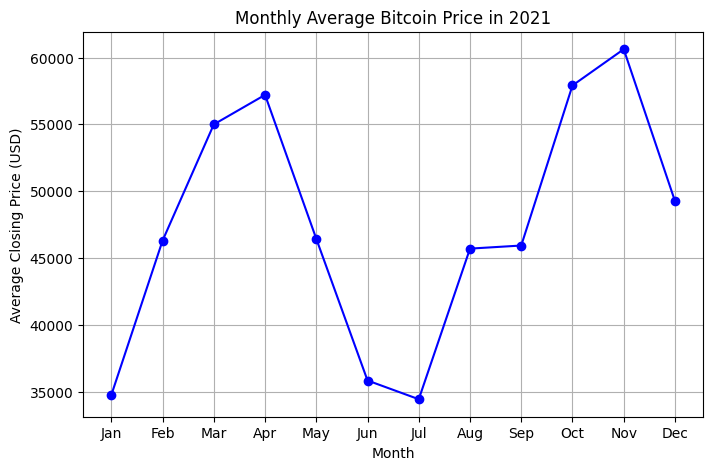

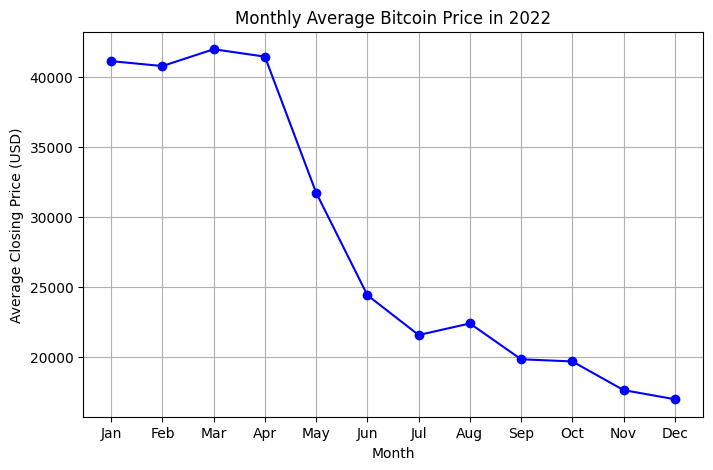

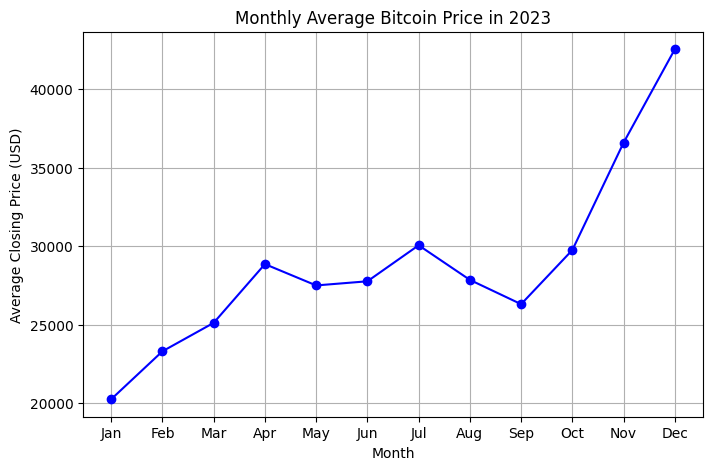

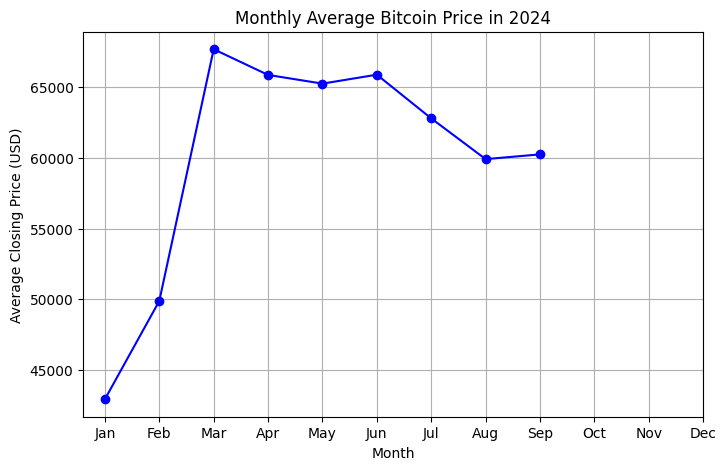

In [67]:
import matplotlib.pyplot as plt

# Get the list of years present in the dataset
years = range(2015, 2025)  # From 2015 to 2024

# Loop through each year and plot
for year in years:
    # Filter the monthly averages for the current year
    monthly_data = monthly_avg[year]
    
    # Create the plot
    plt.figure(figsize=(8, 5))
    plt.plot(monthly_data.index, monthly_data.values, marker='o', color='b')
    
    # Customize the plot
    plt.title(f'Monthly Average Bitcoin Price in {year}')
    plt.xlabel('Month')
    plt.ylabel('Average Closing Price (USD)')
    plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.grid(True)
    
    # Show the plot for the current year
    plt.show()


In [19]:
# Create a column for daily returns
df['Daily_Return'] = df['Close'].pct_change()

# Create rolling averages (7-day and 30-day moving averages)
df['7-day MA'] = df['Close'].rolling(window=7).mean()
df['30-day MA'] = df['Close'].rolling(window=30).mean()



In [22]:
df.head()

,Date,Open,High,Low,Close,Volume,Month,Day,Year,Daily_Return,7-day MA,30-day MA
0,2015-01-01,320.434998,320.434998,314.002991,314.248993,8036550,1,1,2015,NaN,NaN,NaN
1,2015-01-02,314.079010,315.838989,313.565002,315.032013,7860650,1,2,2015,0.002492,NaN,NaN
2,2015-01-03,314.846008,315.149994,281.082001,281.082001,33054400,1,3,2015,-0.107767,NaN,NaN
3,2015-01-04,281.145996,287.230011,257.612000,264.195007,55629100,1,4,2015,-0.060079,NaN,NaN
4,2015-01-05,265.084015,278.341003,265.084015,274.473999,43962800,1,5,2015,0.038907,NaN,NaN


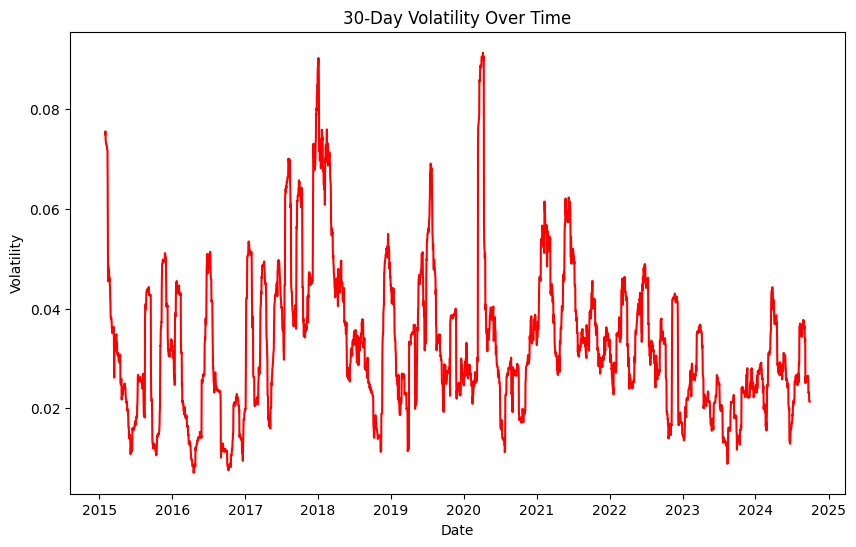

In [27]:
# Calculate 30-day volatility
df['30-day Volatility'] = df['Daily_Return'].rolling(window=30).std()

plt.figure(figsize=(10,6))
plt.plot(df['Date'], df['30-day Volatility'], color='r')
plt.title('30-Day Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()


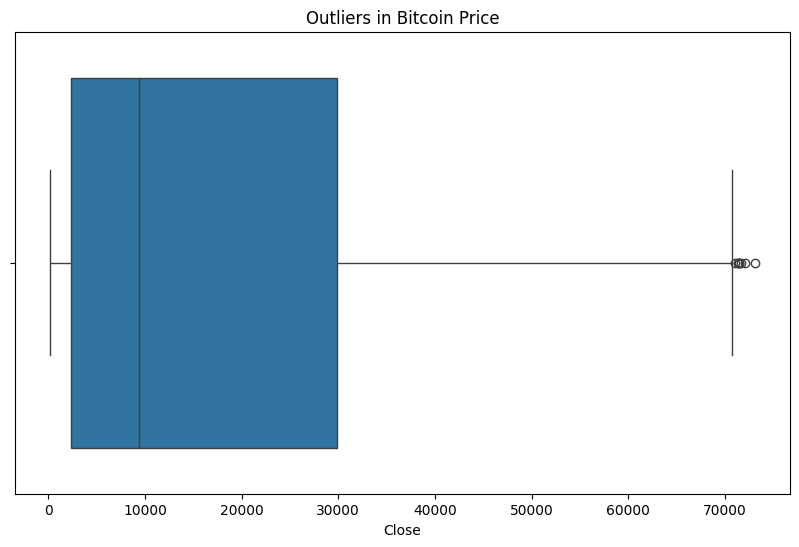

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Close'])
plt.title('Outliers in Bitcoin Price')
plt.show()


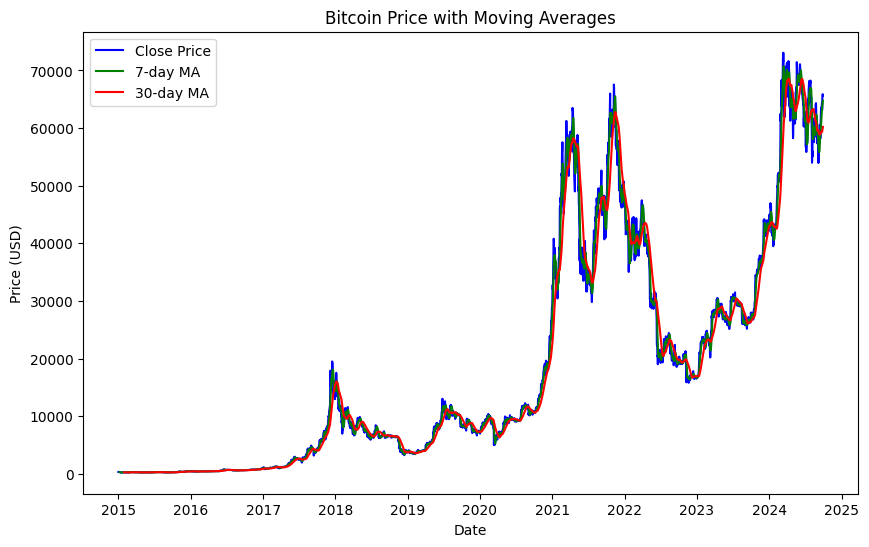

In [30]:
plt.figure(figsize=(10,6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='b')
plt.plot(df['Date'], df['7-day MA'], label='7-day MA', color='g')
plt.plot(df['Date'], df['30-day MA'], label='30-day MA', color='r')
plt.title('Bitcoin Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()
